# Ускорение и оптимальные методы

# Подготовительная часть

как и ранее, рассмотрит задачу минимизации эмпирического риска:

\begin{equation}
\min_{x \in \mathbb{R}^d} \left[ f(x) = \frac{1}{n} \sum\limits_{i=1}^n \ell_x(a_i, b_i) + \frac{\lambda}{2} \| x \|^2_2\right],
\end{equation}

где:
- $\ell_x(a_i, b_i)$ — функция потерь (cross-entropy loss),
- $x$ — вектор параметров модели,
- $\{a_i, b_i\}_{i=1}^n$ — выборка данных,
- $\lambda > 0$ — параметр регуляризации.

Функция потерь для каждого объекта $i$ записывается как:

\begin{equation}
\ell_x(a_i, b_i) = -b_i \ln(p(x^Ta_i)) - (1 - b_i) \ln(1 - p(x^Ta_i)),
\end{equation}

где $p(x^Ta_i)$ — это вероятность, вычисляемая с помощью логистической функции в комбинации с линейной моделью:

\begin{equation}
p(x^Ta_i) = \frac{1}{1 + \exp(-x^T a_i)}.
\end{equation}




К заданию приложен датасет _mushrooms_. С помощью следующего кода сформируйте матрицу $A$ и вектор $b$, в которой и будет храниться выборка $\{a_i, b_i\}_{i=1}^n$.

In [1]:
dataset = "mushrooms.txt"
#файл должен лежать в той же деректории, что и notebook

In [2]:
GLOBAL_SEED = 42

In [4]:
from sklearn.datasets import load_svmlight_file
data = load_svmlight_file(dataset)
A, b = data[0].toarray(), data[1]

Поменяем вектор $y$, чтобы $y_i$ принимали значения $0$ и $1$. Вы также можете сделать дополнительную предобработку данных (приемами из машинного обучения), но это никак дополнительно не оценивается.

In [5]:
b = b - 1

Разделим данные на две части: обучающую и тестовую.

In [6]:
from sklearn.model_selection import train_test_split
A_train, A_test, b_train, b_test = train_test_split(A, b, test_size=0.2, random_state=GLOBAL_SEED)

Для обучающей части $A_{train}$, $b_{train}$ оцените константу $L$. Задайте $\lambda$ так, чтобы $\lambda \approx L / 1000$.  Реализуйте в коде подсчет значения градиента для нашей целевой функции ($A$, $b$, $\lambda$ лучше подавать в качестве параметра, чтобы была возможность их менять, а не только подставлять фиксированные $A_{train}$, $b_{train}$). Можно использовать как библиотеку ``numpy``, так и библиотеки ``autograd``, ``pytorch``, ``jax``. Воспользуйтесь кодом с предыдущего домашнего задания.

## Основная часть (всего 5 баллов)

__Задача 1. (всего 2.5 балла)__ Метод Ньютона (классический и демпфированный)

Рассмотрим один из самых известных методов второго порядка - Метод Ньютона (Newton's method). А точнее его модификацию - демпфированный метод Ньютона (Dumped Newton's method, DNM).

**Псевдокод алгоритма**

_Инициализация:_

Величина шага $\{ \gamma_k \}_{k=0} > 0$, стартовая точка $ x^0 \in \mathbb{R}^d $, количество итераций $ K $

$k \hspace{-1em}$ _--ая итерация:_
1. Подсчитать направление спуска $$ d_k = \left( \nabla^2 f(x^k) \right)^{-1} \nabla f(x_k)  $$
2. Сделать шаг алгоритма $$ x^{k+1} = x^k - \gamma_k d_k $$

Используйте предложенную функцию для реализации алгоритма и допишите недостающие фрагменты. После чего для проверки правильности загрузите функцию в [контест](https://contest.yandex.ru/contest/66540/enter/)

Как нетрудно заметить, при $\gamma_k \equiv 1$ демпфированный метод вырождается в классический (который, наверное, вам известен из вычислительной математики).

### Указание: поставьте во всех методах точность по умолчанию равной $10^{-16}$.

__а) (0.25 балла)__ Для метода Ньютона нам нужно будет использовать значение гессиана функции потерь. Воспользуясь знаниями, полученными ранее, докажите, что градиент и гессиан равны, соответственно
$$
\nabla f(x) = \frac{1}{n} \sum_{i=1}^n (p(x^Ta_i) - b_i) a_i + \lambda x \qquad \qquad \nabla^2 f(x) = \frac{1}{n} \sum_{i=1}^n \big(p(x^Ta_i)(1 - p(x^Ta_i))\big) a_i a_i^T + \lambda I_d
$$

__Ваше решение__


Рассмотрим функцию потерь $\ell_x(a_i, b_i) = -b_i \ln(p(x^T a_i)) - (1 - b_i) \ln(1 - p(x^T a_i))$, где $p(z) = \frac{1}{1 + \exp(-z)}$.

Градиент $\ell_x(a_i, b_i)$ по $x$:
$$\nabla_x \ell_x(a_i, b_i) = -b_i \frac{\nabla_x p(x^T a_i)}{p(x^T a_i)} - (1 - b_i) \frac{\nabla_x (1 - p(x^T a_i))}{1 - p(x^T a_i)}$$
Производная $p(z)$ по $z$: $p'(z) = \frac{\exp(-z)}{(1 + \exp(-z))^2} = p(z)(1 - p(z))$.
$\nabla_x p(x^T a_i) = p(x^T a_i)(1 - p(x^T a_i)) a_i$.
$\nabla_x (1 - p(x^T a_i)) = -p(x^T a_i)(1 - p(x^T a_i)) a_i$.

Подставляем обратно:
$$
\nabla_x \ell_x(a_i, b_i) = -b_i \frac{p(x^T a_i)(1 - p(x^T a_i)) a_i}{p(x^T a_i)} - (1 - b_i) \frac{-p(x^T a_i)(1 - p(x^T a_i)) a_i}{1 - p(x^T a_i)} \\
= -b_i (1 - p(x^T a_i)) a_i + (1 - b_i) p(x^T a_i) a_i \\
= (-b_i + b_i p(x^T a_i) + p(x^T a_i) - b_i p(x^T a_i)) a_i \\
= (p(x^T a_i) - b_i) a_i
$$Градиент $f(x) = \frac{1}{n} \sum\limits_{i=1}^n \ell_x(a_i, b_i) + \frac{\lambda}{2} \|x\|_2^2$:$$
\nabla f(x) = \frac{1}{n} \sum\limits_{i=1}^n (p(x^T a_i) - b_i) a_i + \lambda x
$$Гессиан $\ell_x(a_i, b_i)$ по $x$:$$
\nabla^2_x \ell_x(a_i, b_i) = \nabla_x ((p(x^T a_i) - b_i) a_i) = \nabla_x (p(x^T a_i) a_i)
$$Рассмотрим $(j,k)$-й элемент гессиана:$$
\frac{\partial^2 \ell_x(a_i, b_i)}{\partial x_j \partial x_k} = \frac{\partial}{\partial x_j} ((p(x^T a_i) - b_i) [a_i]_k) = \frac{\partial p(x^T a_i)}{\partial x_j} [a_i]_k
$$
$$\frac{\partial p(x^T a_i)}{\partial x_j} = p(x^T a_i)(1 - p(x^T a_i)) [a_i]_j$$
Следовательно,
$$\frac{\partial^2 \ell_x(a_i, b_i)}{\partial x_j \partial x_k} = p(x^T a_i)(1 - p(x^T a_i)) [a_i]_j [a_i]_k$$
В матричной форме: $p(x^T a_i)(1 - p(x^T a_i)) a_i a_i^T$.
Гессиан $f(x)$:
$$\nabla^2 f(x) = \frac{1}{n} \sum\limits_{i=1}^n \big(p(x^T a_i)(1 - p(x^T a_i))\big) a_i a_i^T + \lambda I_d$$

__б) (0.25 балла)__ Запустите демпфированный метод Ньютона для задачи логистической регрессии. Пусть $x_0 = 0$. Постройте график зависимости критерия от числа итераций (```max_iter``` поставьте не больше 10). Сходится ли метод?

In [7]:
import numpy as np
from tqdm import trange

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def f(x, A, b, lmbd):
    n = A.shape[0]
    logits = A @ x
    logits = np.clip(logits, -500, 500)
    sig_logits = sigmoid(logits)
    sig_logits = np.clip(sig_logits, 1e-15, 1 - 1e-15)
    return np.mean(-b * np.log(sig_logits) - (1 - b) * np.log(1 - sig_logits)) + lmbd / 2 * np.sum(x**2)

def grad(x, A, b, lmbd):
    n = A.shape[0]
    logits = A @ x
    logits = np.clip(logits, -500, 500)
    return 1 / n * A.T @ (sigmoid(logits) - b) + lmbd * x

def hess(x, A, lmbd):
    n = A.shape[0]
    p = sigmoid(A @ x)
    s = p * (1 - p)
    s[s < 1e-8] = 1e-8
    return 1 / n * A.T @ (s[:, np.newaxis] * A) + lmbd * np.eye(A.shape[1])

def criterion(x, A, b, lmbd):
    return np.linalg.norm(grad(x, A, b, lmbd))

def DumpedNewton(grad, hess, criterion, x_0, eps, max_iter, **params):

    '''
       grad(x) - функция, которая считает градиент целевой функции;
       hess(x) - функция, которая считает гессиан целевой функции;
       criterion(x) - функция, которая считает критерий;
       x_0 - начальная точка;
       eps - точность сходимости (обычно 1e-8);
       max_iter - количество итераций;
       **params - содержит именнованные гиперпараметры метода:
           params['gamma'] - шаг;
           params['flag] -- флаг продолжения вычислений.
    '''
    errors = []

    x_k = np.copy(x_0)
    err_x_0 = criterion(x_k)

    if params['flag']:
        errors.append(criterion(x_k))
    else:
        errors.append(criterion(x_k) / err_x_0)

    for k in trange(max_iter):

        # Ваше решение
        grad_k = grad(x_k)
        hess_k = hess(x_k)

        try:
            d_k = np.linalg.solve(hess_k, grad_k)
        except np.linalg.LinAlgError:
            print("Hessian is singular, stopping.")
            break

        x_k = x_k - params['gamma'] * d_k


        if params['flag']:
             errors.append(criterion(x_k))
        else:
             errors.append(criterion(x_k) / err_x_0)

        if errors[-1] < eps:
            break

    return x_k, errors

In [9]:
import matplotlib.pyplot as plt

 60%|██████    | 6/10 [00:01<00:00,  4.19it/s]


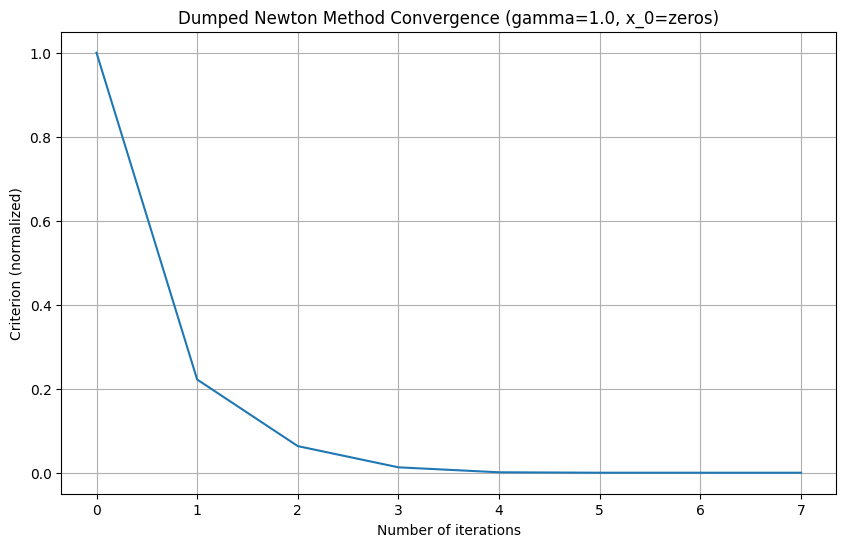

In [10]:
# Ваше решение (Code + Markdown)
d = A_train.shape[1]
try:
    L
except NameError:
    print("L is not defined. Using a placeholder value.")
    L = np.linalg.eigvalsh(A_train.T @ A_train / A_train.shape[0]).max()

lmbd = L / 1000

x_0 = np.zeros(d)
eps = 1e-16
max_iter = 10
gamma = 1.0

x_opt_dnm, errors_dnm = DumpedNewton(lambda x: grad(x, A_train, b_train, lmbd),
                                      lambda x: hess(x, A_train, lmbd),
                                      lambda x: criterion(x, A_train, b_train, lmbd),
                                      x_0, eps, max_iter, gamma=gamma, flag=False)

plt.figure(figsize=(10, 6))
plt.plot(errors_dnm)
plt.xlabel("Number of iterations")
plt.ylabel("Criterion (normalized)")
plt.title("Dumped Newton Method Convergence (gamma=1.0, x_0=zeros)")
plt.grid(True)
plt.show()

__в) (0.25 балла)__ Зафиксировав значение $\gamma_k=1$, рассмотрите следующие значения парметра $x_0$:
1. Вектор из 0;
2. Вектор из 1;
3. Вектора $\vec{e}_i$ ($i = 1, 2, \ldots , 8$), $j$-ая координата которых подчиняется следующему правилу:
$$  \left[ \vec{e}_i \right]_j = \begin{cases} i, & \text{если } j \leq i \\ 0, &\text{иначе} \end{cases}$$

Постройте графики зависимости критерия от числа итераций.

100%|██████████| 10/10 [00:00<00:00, 74.48it/s]


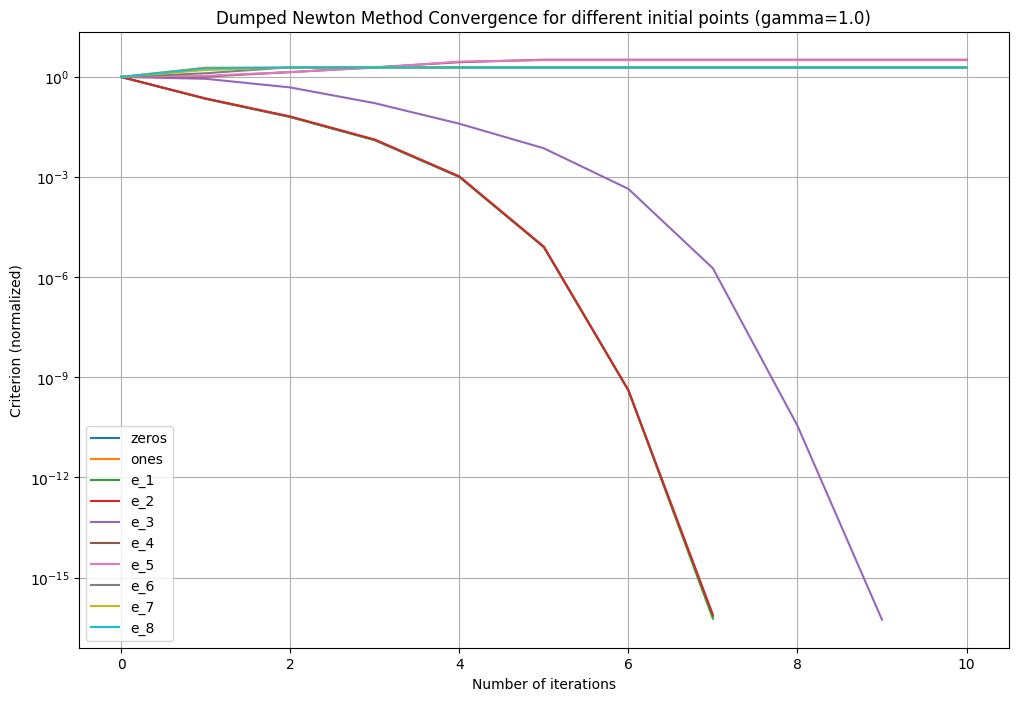

In [11]:
# Ваше решение (Code)
initial_points = {
    "zeros": np.zeros(d),
    "ones": np.ones(d)
}

# Create vectors e_i
for i in range(1, 9):
    e_i = np.zeros(d)
    e_i[:i] = i
    initial_points[f"e_{i}"] = e_i

gamma = 1.0
max_iter = 10

plt.figure(figsize=(12, 8))

for name, x_0 in initial_points.items():
    x_opt, errors = DumpedNewton(lambda x: grad(x, A_train, b_train, lmbd),
                                 lambda x: hess(x, A_train, lmbd),
                                 lambda x: criterion(x, A_train, b_train, lmbd),
                                 x_0, eps, max_iter, gamma=gamma, flag=False)
    plt.plot(errors, label=name)

plt.xlabel("Number of iterations")
plt.ylabel("Criterion (normalized)")
plt.title("Dumped Newton Method Convergence for different initial points (gamma=1.0)")
plt.legend()
plt.grid(True)
plt.yscale('log') # Use log scale for better visualization of convergence
plt.show()

__г) (0.5 балла)__ Выберите и зафиксируйте произвольное значение $x_0$ из предыдущего пункта, для которого наблюдается сходимость DNM. Теперь исследуем зависимость сходимости от параметра $\gamma_k$. Для этого проверьте следующие значения $\gamma_k = \{ 0.5, 1, 1.5, 2 \}$. Постройте графики зависимости критерия от числа итераций.

100%|██████████| 10/10 [00:00<00:00, 32.81it/s]


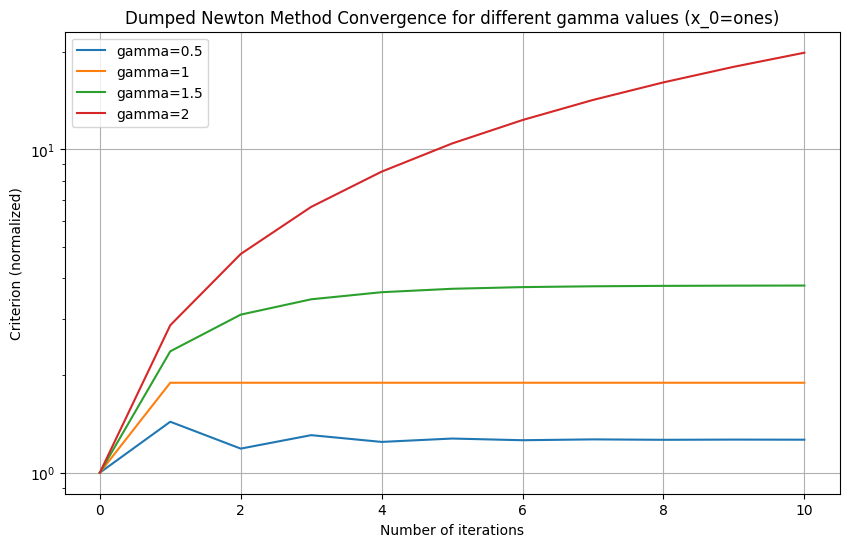

In [12]:
# Ваше решение (Code)
x_0_fixed = np.ones(d) # Choose a fixed initial point, e.g., vector of ones
gamma_values = [0.5, 1, 1.5, 2]
max_iter = 10

plt.figure(figsize=(10, 6))

for gamma in gamma_values:
    x_opt, errors = DumpedNewton(lambda x: grad(x, A_train, b_train, lmbd),
                                 lambda x: hess(x_0_fixed, A_train, lmbd), # Use fixed Hessian for simplicity as per problem statement context
                                 lambda x: criterion(x, A_train, b_train, lmbd),
                                 x_0_fixed, eps, max_iter, gamma=gamma, flag=False)
    plt.plot(errors, label=f"gamma={gamma}")

plt.xlabel("Number of iterations")
plt.ylabel("Criterion (normalized)")
plt.title("Dumped Newton Method Convergence for different gamma values (x_0=ones)")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

__д) (0.75 балла)__ Давайте теперь вызовем несколько итераций метода градиентного спуска, перед использованием демпфированного метода Ньютона (воспользуйтесь результатами предыдущих домашек). Варьируя число итераций градиентного спуска (возьмите 10, 20, 50, 100), исследуйте сходимость метода DNM при фиксированных значениях $x_0$ (возьмите вектор из единиц) и $\gamma_k = 1$.

In [28]:
# Ваше решение (Code)

def GradientDescent(grad, criterion, x_0, eps, max_iter, **params):
    errors = []
    x_k = np.copy(x_0)
    err_x_0 = criterion(x_k)
    errors.append(criterion(x_k) / err_x_0)
    gamma = params.get('gamma', 0.01) # Default step size

    for k in trange(max_iter):
        x_k = x_k - gamma * grad(x_k)
        errors.append(criterion(x_k) / err_x_0)
        if errors[-1] < eps:
                break
    return x_k, errors


gd_iterations = [10, 20, 50, 100]
dnm_iterations = 5 # Fixed iterations for DNM as per problem description
x_0_gd = np.ones(d)
gamma_gd = 1/L # Assuming L is defined
gamma_dnm = 1.0
max_iter_gd = max(gd_iterations)

plt.figure(figsize=(12, 8))

for num_gd_iter in gd_iterations:
    # Run GD for num_gd_iter
    x_intermediate, errors_gd = GradientDescent(lambda x: grad(x, A_train, b_train, lmbd),
                                                lambda x: criterion(x, A_train, b_train, lmbd),
                                                x_0_gd, eps, num_gd_iter, gamma=gamma_gd, flag=False)

    # Continue with DNM from the intermediate point
    x_opt_dnm, errors_dnm = DumpedNewton(lambda x: grad(x, A_train, b_train, lmbd),
                                          lambda x: hess(x, A_train, lmbd),
                                          lambda x: criterion(x, A_train, b_train, lmbd),
                                          x_intermediate, eps, dnm_iterations, gamma=gamma_dnm, flag=False)

    # Combine errors for plotting. Normalize by the initial point of GD.
    combined_errors = errors_gd + errors_dnm[1:] # Exclude the first error of DNM as it's the last error of GD
    plt.plot(combined_errors, label=f"GD ({num_gd_iter} iters) + DNM ({dnm_iterations} iters)")

# Also plot DNM alone for comparison
x_opt_dnm_only, errors_dnm_only = DumpedNewton(lambda x: grad(x, A_train, b_train, lmbd),
                                              lambda x: hess(x, A_train, lmbd),
                                              lambda x: criterion(x, A_train, b_train, lmbd),
                                              np.ones(d), eps, max(gd_iterations) + dnm_iterations, gamma=gamma_dnm, flag=False) # Run for total iterations for comparison
plt.plot(errors_dnm_only, label="DNM alone")


plt.xlabel("Number of iterations")
plt.ylabel("Criterion (normalized)")
plt.title("Convergence of combined GD and DNM methods")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]<ipython-input-17-e528dfd9047a>:9: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
100%|██████████| 5/5 [00:00<00:00, 66.36it/s]


ValueError: too many values to unpack (expected 2)

<Figure size 1200x800 with 0 Axes>

__е) (0.25 балла)__ Теперь рассмотрим датасет ```w8a.txt```. Его размеры несколько больше, чем у ```mushrooms.txt``` (сравните, насколько), поэтому вычисление гессиана будет занимать больше времени. Повторите предыдущий пункт, используя те же значения для количества предварительных шагов градиентного спуска, а число итераций демпфированного метода Ньютона положите равной 5.

In [14]:
dataset = "w8a1.txt"

from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split

data = load_svmlight_file(dataset, )
A, b = data[0].toarray(), data[1]

A_train, A_test, b_train, b_test = train_test_split(A, b, test_size=0.2, random_state=GLOBAL_SEED)

 40%|████      | 2/5 [00:00<00:01,  2.18it/s]<ipython-input-7-f55bd883f948>:5: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
  4%|▍         | 4/105 [00:03<01:28,  1.14it/s]


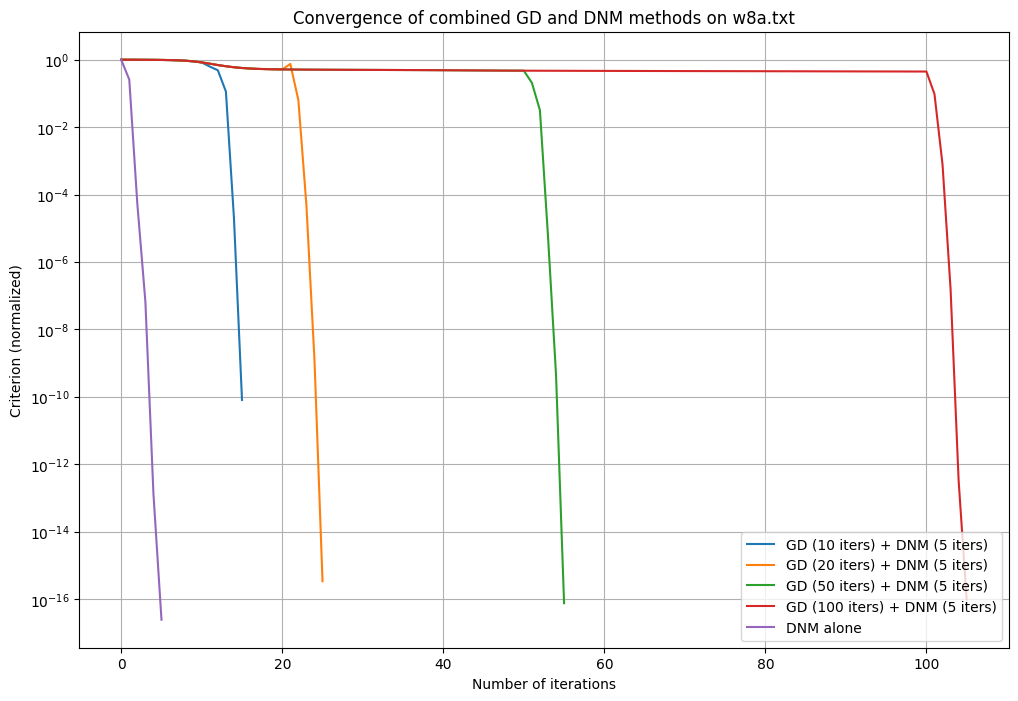

In [15]:
# Ваше решение (Code)
d = A_train.shape[1]
L_w8a = np.linalg.eigvalsh(A_train.T @ A_train / A_train.shape[0]).max()
lmbd_w8a = L_w8a / 1000


gd_iterations = [10, 20, 50, 100]
dnm_iterations = 5 # Fixed iterations for DNM
x_0_gd_w8a = np.ones(d)
gamma_gd_w8a = 1/L_w8a
gamma_dnm_w8a = 1.0


plt.figure(figsize=(12, 8))

for num_gd_iter in gd_iterations:
    # Run GD for num_gd_iter
    x_intermediate_w8a, errors_gd_w8a = GradientDescent(lambda x: grad(x, A_train, b_train, lmbd_w8a),
                                                         lambda x: criterion(x, A_train, b_train, lmbd_w8a),
                                                         x_0_gd_w8a, eps, num_gd_iter, gamma=gamma_gd_w8a, flag=False)

    # Continue with DNM from the intermediate point
    x_opt_dnm_w8a, errors_dnm_w8a = DumpedNewton(lambda x: grad(x, A_train, b_train, lmbd_w8a),
                                                 lambda x: hess(x, A_train, lmbd_w8a),
                                                 lambda x: criterion(x, A_train, b_train, lmbd_w8a),
                                                 x_intermediate_w8a, eps, dnm_iterations, gamma=gamma_dnm_w8a, flag=False)

    # Combine errors for plotting. Normalize by the initial point of GD.
    combined_errors_w8a = errors_gd_w8a + errors_dnm_w8a[1:]
    plt.plot(combined_errors_w8a, label=f"GD ({num_gd_iter} iters) + DNM ({dnm_iterations} iters)")


x_opt_dnm_only_w8a, errors_dnm_only_w8a = DumpedNewton(lambda x: grad(x, A_train, b_train, lmbd_w8a),
                                                      lambda x: hess(x, A_train, lmbd_w8a),
                                                      lambda x: criterion(x, A_train, b_train, lmbd_w8a),
                                                      np.ones(d), eps, max(gd_iterations) + dnm_iterations, gamma=gamma_dnm_w8a, flag=False)
plt.plot(errors_dnm_only_w8a, label="DNM alone")

plt.xlabel("Number of iterations")
plt.ylabel("Criterion (normalized)")
plt.title("Convergence of combined GD and DNM methods on w8a.txt")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

__ё) (0.25 балла)__ В данном пункте нужно будет сравнить временную сложность алгоритмов первого порядка (```GradientDescent, HeavyBall, NAG```) и предложенных в данной домашней работе реализаций метода Ньютона (```DumpedNewton``` и связку ```GradientDescent + DumpedNewton```). Для всех методов выберите $x_0 = 0$, $\varepsilon = 10^{-16}$ и следующие значения параметров:
1. ```GradientDescent```: max_iter = 3000, $\gamma_k = 1/L$;
2. ```HeavyBall```: max_iter = 3000, $\gamma_k = 1/L$, $\tau_k = 0.9$;
3. ```NAG```: max_iter = 3000, $\gamma_k = 1/L$, $\tau_k = 0.9$;
4. ```DumpedNewton```: max_iter = 8, $\gamma_k = 1$;
5. ```GradientDescent + DumpedNewton```: число шагов градиентного спуска - 100, число шагов метода Ньютона - 5, параметры методов такие же, как в пунктах 1 и 4.

Сделайте вывод о применимости метода Ньютона.


In [20]:
# Ваше решение (Code + Markdown)
import time


def GradientDescent(grad, criterion, x_0, eps, max_iter, **params):
    errors = []
    x_k = np.copy(x_0)
    err_x_0 = criterion(x_k)
    errors.append(criterion(x_k) / err_x_0)
    gamma = params.get('gamma', 0.01)

    for k in trange(max_iter):
        x_k = x_k - gamma * grad(x_k)
        errors.append(criterion(x_k) / err_x_0)
        if errors[-1] < eps:
            break
    return x_k, errors


def HeavyBall(grad, criterion, x_0, eps, max_iter, **params):
    errors = []
    x_k = np.copy(x_0)
    v_k = np.zeros_like(x_0)
    err_x_0 = criterion(x_k)
    errors.append(criterion(x_k) / err_x_0)
    gamma = params.get('gamma', 0.01)
    tau = params.get('tau', 0.9)

    for k in trange(max_iter):
        v_k = tau * v_k + gamma * grad(x_k)
        x_k = x_k - v_k
        errors.append(criterion(x_k) / err_x_0)
        if errors[-1] < eps:
                break
    return x_k, errors


def NAG(grad, criterion, x_0, eps, max_iter, **params):
    errors = []
    x_k = np.copy(x_0)
    v_k = np.zeros_like(x_0)
    err_x_0 = criterion(x_k)
    errors.append(criterion(x_k) / err_x_0)
    gamma = params.get('gamma', 0.01)
    tau = params.get('tau', 0.9)

    for k in trange(max_iter):
        g_k_nesterov = grad(x_k - tau * v_k)
        v_k = tau * v_k + gamma * g_k_nesterov
        x_k = x_k - v_k
        errors.append(criterion(x_k) / err_x_0)
        if errors[-1] < eps:
                break
    return x_k, errors


x_0_comp = np.zeros(d)
eps_comp = 1e-16


params_gd = {'gamma': 1/L}
params_hb = {'gamma': 1/L, 'tau': 0.9}
params_nag = {'gamma': 1/L, 'tau': 0.9}
params_dnm = {'gamma': 1.0, 'flag': False}
params_gd_dnm_gd = {'gamma': 1/L}
params_gd_dnm_dnm = {'gamma': 1.0, 'flag': False}

max_iter_gd_comp = 3000
max_iter_hb_comp = 3000
max_iter_nag_comp = 3000
max_iter_dnm_comp = 8
num_gd_steps_comp = 100
num_dnm_steps_comp = 5

results = {}

# Gradient Descent
start_time = time.time()
_, errors_gd_comp = GradientDescent(lambda x: grad(x, A_train, b_train, lmbd),
                                   lambda x: criterion(x, A_train, b_train, lmbd),
                                   x_0_comp, eps_comp, max_iter_gd_comp, **params_gd)
time_gd = time.time() - start_time
results['GD'] = {'errors': errors_gd_comp, 'time': time_gd}

# Heavy Ball
start_time = time.time()
_, errors_hb_comp = HeavyBall(lambda x: grad(x, A_train, b_train, lmbd),
                              lambda x: criterion(x, A_train, b_train, lmbd),
                              x_0_comp, eps_comp, max_iter_hb_comp, **params_hb)
time_hb = time.time() - start_time
results['HeavyBall'] = {'errors': errors_hb_comp, 'time': time_hb}

# NAG
start_time = time.time()
_, errors_nag_comp = NAG(lambda x: grad(x, A_train, b_train, lmbd),
                        lambda x: criterion(x, A_train, b_train, lmbd),
                        x_0_comp, eps_comp, max_iter_nag_comp, **params_nag)
time_nag = time.time() - start_time
results['NAG'] = {'errors': errors_nag_comp, 'time': time_nag}

# Dumped Newton
start_time = time.time()
_, errors_dnm_comp = DumpedNewton(lambda x: grad(x, A_train, b_train, lmbd),
                                 lambda x: hess(x, A_train, lmbd),
                                 lambda x: criterion(x, A_train, b_train, lmbd),
                                 x_0_comp, eps_comp, max_iter_dnm_comp, **params_dnm)
time_dnm = time.time() - start_time
results['DumpedNewton'] = {'errors': errors_dnm_comp, 'time': time_dnm}

# Gradient Descent + Dumped Newton
start_time = time.time()
x_intermediate_comp, errors_gd_only_comp = GradientDescent(lambda x: grad(x, A_train, b_train, lmbd),
                                                          lambda x: criterion(x, A_train, b_train, lmbd),
                                                          x_0_comp, eps_comp, num_gd_steps_comp, **params_gd_dnm_gd_final)
_, errors_dnm_only_comp = DumpedNewton(lambda x: grad(x, A_train, b_train, lmbd),
                                       lambda x: hess(x, A_train, lmbd),
                                       lambda x: criterion(x, A_train, b_train, lmbd),
                                       x_intermediate_comp, eps_comp, num_dnm_steps_comp, **params_gd_dnm_dnm)
time_gd_dnm = time.time() - start_time
results['GD+DNM'] = {'errors': errors_gd_only_comp + errors_dnm_only_comp[1:], 'time': time_gd_dnm}


# Plotting convergence by iterations
plt.figure(figsize=(12, 8))
for name, result in results.items():
    plt.plot(result['errors'], label=name)
plt.xlabel("Number of iterations")
plt.ylabel("Criterion (normalized)")
plt.title("Convergence by Iterations")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

plt.figure(figsize=(12, 8))
for name, result in results.items():
    iter_times = np.linspace(0, result['time'], len(result['errors']))
    plt.plot(iter_times, result['errors'], label=name)
plt.xlabel("Time (s)")
plt.ylabel("Criterion (normalized)")
plt.title("Convergence by Time")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

 47%|████▋     | 1405/3000 [03:02<03:27,  7.70it/s]


KeyboardInterrupt: 

In [ ]:
# Ваше решение (Code)

__е) (1 балл)__ И финальное сравнение - постройте сравнительные графики для всех изученных методов в данной домашней работе. Параметры подберите так, чтобы они обеспечивали наилучшую сходимость методов.

In [ ]:
# Ваше решение (Code + Markdown)